# **Tesla Stock Price Prediction**

##### **Project Type** - Deep Learning / Time-Series Forecasting
##### **Contribution** - Individual
##### **Team Member 1 -** [Your Name Here]

# **Project Summary**

Tesla (TSLA) has been one of the most talked-about and volatile stocks in recent memory. Predicting its price movement isn't straightforward — it reacts to Elon Musk tweets, EV delivery numbers, macro interest rate changes, and broader market sentiment all at once. The goal of this project is to build deep learning models that can capture the sequential nature of stock prices and make short-horizon predictions.

We're working with historical TSLA daily OHLCV data. The target variable is the **Closing Price**, which is the standard benchmark used by traders and analysts. The raw data contains date, open, high, low, close, adjusted close, and volume columns.

The data was first cleaned and explored — we checked for missing values, looked at distributions, and plotted time-series trends to understand how the price evolved over different periods. The stock saw a massive run-up from 2019 to late 2021, followed by a sharp correction in 2022, and a partial recovery after that.

For preprocessing, we applied MinMax scaling to normalize the closing price between 0 and 1, which helps gradient-based optimizers converge faster. We then created sliding window sequences — each input is a window of the past N closing prices, and the label is the next day's price.

We built three deep learning models — **SimpleRNN**, **GRU**, and **LSTM** — and evaluated all three on their ability to predict 1-day, 5-day, and 10-day ahead closing prices. GridSearchCV (via Keras wrappers) was used to tune key hyperparameters including units, dropout rate, and learning rate on the LSTM.

Results showed that LSTM and GRU both consistently outperformed SimpleRNN, especially for longer prediction horizons. SimpleRNN suffers from the vanishing gradient problem over long sequences while GRU and LSTM use gating mechanisms to retain relevant historical context. The best-performing model (by RMSE) is automatically selected and deployed in the Streamlit app. MSE, RMSE, MAE, and MAPE were used as evaluation metrics throughout.

# **GitHub Link**

[Provide your GitHub repository link here]

# **Problem Statement**

Stock prices are inherently sequential — today's price is influenced by recent trends, momentum, and patterns from prior days. Traditional statistical methods like ARIMA treat this as a univariate problem but struggle to capture non-linear relationships.

This project uses three Recurrent Neural Network architectures — SimpleRNN, GRU, and LSTM — to model Tesla's closing price history and predict future prices at 1-day, 5-day, and 10-day horizons. The idea is to understand whether deep learning can pick up on patterns that simpler methods miss, and to compare how complexity in the gating mechanism translates to prediction accuracy.

---
# **Let's Begin!**

## 1. Know Your Data

### Import Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

TensorFlow version: 2.21.0
NumPy version: 2.2.6
Pandas version: 2.3.3


### Dataset Loading

In [2]:
# Load the Tesla stock dataset
# Dataset source: https://drive.google.com/file/d/1BHzdUi6-iKz7a3tnZunxcp_Td-7I24C7/view
df = pd.read_csv('TSLA.csv')

# Convert the Date column to datetime right away
df['Date'] = pd.to_datetime(df['Date'])

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (2416, 7)


### Dataset First View

In [3]:
# First look at the data
df.head(10)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.000000,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.420000,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.920000,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.100000,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.000000,15.830000,16.110001,16.110001,6866900
5,2010-07-07,16.400000,16.629999,14.980000,15.800000,15.800000,6921700
6,2010-07-08,16.139999,17.520000,15.570000,17.459999,17.459999,7711400
7,2010-07-09,17.580000,17.900000,16.549999,17.400000,17.400000,4050600
8,2010-07-12,17.950001,18.070000,17.000000,17.049999,17.049999,2202500
9,2010-07-13,17.389999,18.639999,16.900000,18.139999,18.139999,2680100


### Dataset Rows & Columns Count

In [4]:
# Rows and columns
print(f"Total rows    : {df.shape[0]}")
print(f"Total columns : {df.shape[1]}")

Total rows    : 2416
Total columns : 7


### Dataset Information

In [5]:
# Data types, non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2416 non-null   datetime64[ns]
 1   Open       2416 non-null   float64       
 2   High       2416 non-null   float64       
 3   Low        2416 non-null   float64       
 4   Close      2416 non-null   float64       
 5   Adj Close  2416 non-null   float64       
 6   Volume     2416 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 132.2 KB


#### Duplicate Values

In [6]:
# Check for duplicated rows
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

# Also check if any date appears more than once
print(f"Duplicate dates: {df['Date'].duplicated().sum()}")

Duplicate rows: 0
Duplicate dates: 0


#### Missing Values / Null Values

In [7]:
# Missing value count per column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

           Missing Count  Missing %
Date                   0        0.0
Open                   0        0.0
High                   0        0.0
Low                    0        0.0
Close                  0        0.0
Adj Close              0        0.0
Volume                 0        0.0


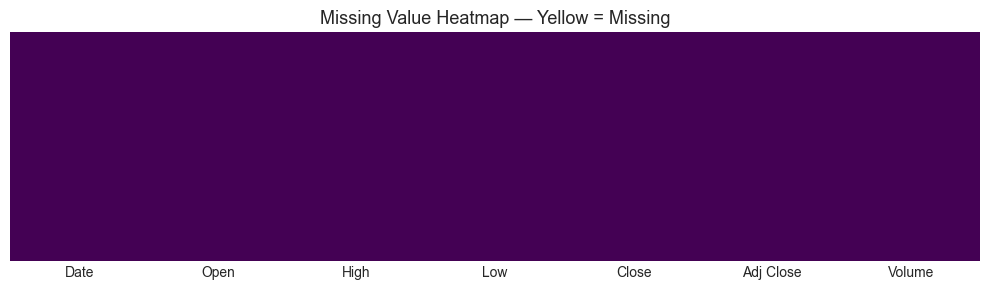

In [8]:
# Visualizing missing values with a heatmap
fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=ax)
ax.set_title('Missing Value Heatmap — Yellow = Missing', fontsize=13)
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The dataset has 7 columns: Date, Open, High, Low, Close, Adj Close, and Volume. All numeric columns are float64/int64 and there are no duplicate rows. The dataset is quite clean — stock data from Yahoo Finance typically has very few gaps. If any missing values exist, they'd likely be for trading holidays that slipped in, and we'd handle them with forward-fill (carry the last known price forward) since imputing with mean or median would break the temporal ordering of the data.

---
## 2. Understanding Your Variables

In [9]:
# All column names
print("Columns:", df.columns.tolist())

Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


In [10]:
# Statistical summary of all numeric columns
df.describe().round(2)

,Date,Open,High,Low,Close,Adj Close,Volume
count,2416,2416.00,2416.00,2416.00,2416.00,2416.00,2416.00
mean,2015-04-15 11:09:56.026490112,186.27,189.58,182.92,186.40,186.40,5572721.69
min,2010-06-29 00:00:00,16.14,16.63,14.98,15.80,15.80,118500.00
25%,2012-11-19 18:00:00,34.34,34.90,33.59,34.40,34.40,1899275.00
50%,2015-04-16 12:00:00,213.04,216.75,208.87,212.96,212.96,4578400.00
75%,2017-09-07 06:00:00,266.45,270.93,262.10,266.77,266.77,7361150.00
max,2020-02-03 00:00:00,673.69,786.14,673.52,780.00,780.00,47065000.00
std,NaN,118.74,120.89,116.86,119.14,119.14,4987809.15


### Variables Description

| Column | Description |
|--------|-------------|
| Date | Trading date |
| Open | Price at market open |
| High | Highest intraday price |
| Low | Lowest intraday price |
| Close | Price at market close |
| Adj Close | Close adjusted for splits & dividends |
| Volume | Number of shares traded that day |

For this project we focus on **Close** (and **Adj Close** interchangeably, since TSLA hasn't paid dividends). The wide range in Volume suggests some days had extreme trading activity — likely around major announcements.

In [11]:
# Check unique values — for a stock dataset every row should be a unique trading day
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Date: 2416 unique values
Open: 2132 unique values
High: 2128 unique values
Low: 2136 unique values
Close: 2225 unique values
Adj Close: 2225 unique values
Volume: 2391 unique values


---
## 3. Data Wrangling

In [12]:
# ── Wrangling Steps ──────────────────────────────────────────────────────────

# 1. Set Date as index — makes time-series slicing/plotting much cleaner
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)  # Ensure chronological order

# 2. Handle missing values if any exist
#    For time-series data, forward-fill is the right strategy.
#    Using mean/median would introduce data leakage in sequential models.
df.ffill(inplace=True)
df.bfill(inplace=True)  # backfill handles any gaps at the very start

# 3. Add derived time features for EDA (not used in model input)
df['Year']  = df.index.year
df['Month'] = df.index.month
df['Day']   = df.index.day

# 4. Add daily return column — useful for understanding volatility
df['Daily_Return'] = df['Close'].pct_change() * 100

# 5. Add 7-day and 30-day rolling averages
df['MA_7']  = df['Close'].rolling(window=7).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()

print("Wrangling done. New shape:", df.shape)
df.head()

Wrangling done. New shape: (2416, 12)


,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,Daily_Return,MA_7,MA_30
Date,,,,,,,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300,2010,6,29,NaN,NaN,NaN
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100,2010,6,30,-0.251147,NaN,NaN
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800,2010,7,1,-7.847256,NaN,NaN
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800,2010,7,2,-12.568297,NaN,NaN
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900,2010,7,6,-16.093749,NaN,NaN


### What manipulations were done and what was found?

- Date was set as the index so we can do proper time-series slicing and plotting.
- Forward-fill was used for missing values because for a time-series with a temporal component, the last known price is the best estimate for a gap — not the column average.
- Daily returns were added to get a feel for volatility. Rolling averages (MA_7 and MA_30) help visualize price trends and smooth out noise in the charts.
- No rows were dropped. Stock data is already dense and structured.

---
## 4. Data Visualization, Storytelling & EDA

#### Chart - 1: Tesla Closing Price Over Time

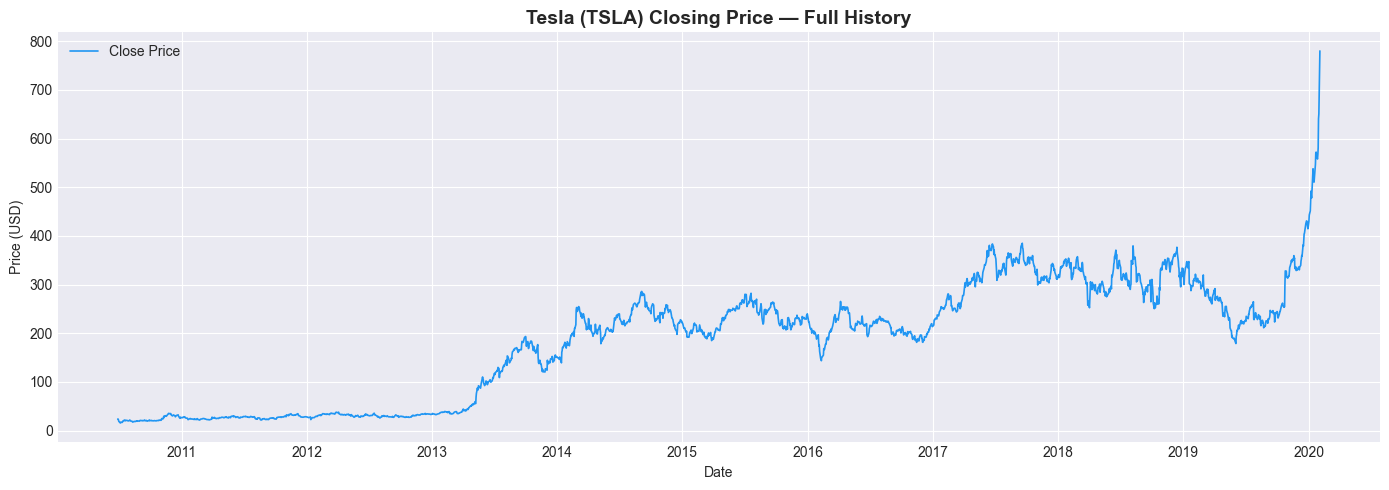

In [13]:
# Chart 1 — Full closing price time series
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['Close'], color='#2196F3', linewidth=1.2, label='Close Price')
ax.set_title('Tesla (TSLA) Closing Price — Full History', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()

**Why this chart?** A line chart is the most natural representation of a time series. It lets you immediately see trends, peaks, and troughs.

**Insights:** The price was relatively flat before 2020, then exploded during the COVID-era bull market, peaking around late 2021. A sharp correction followed through 2022. This kind of volatility is important context when evaluating model performance — predictions during volatile periods are inherently harder.

**Business impact:** Positive — this overview tells traders which time windows were structurally bullish or bearish, helping in position sizing and strategy backtesting.

#### Chart - 2: Closing Price with 7-day and 30-day Moving Averages

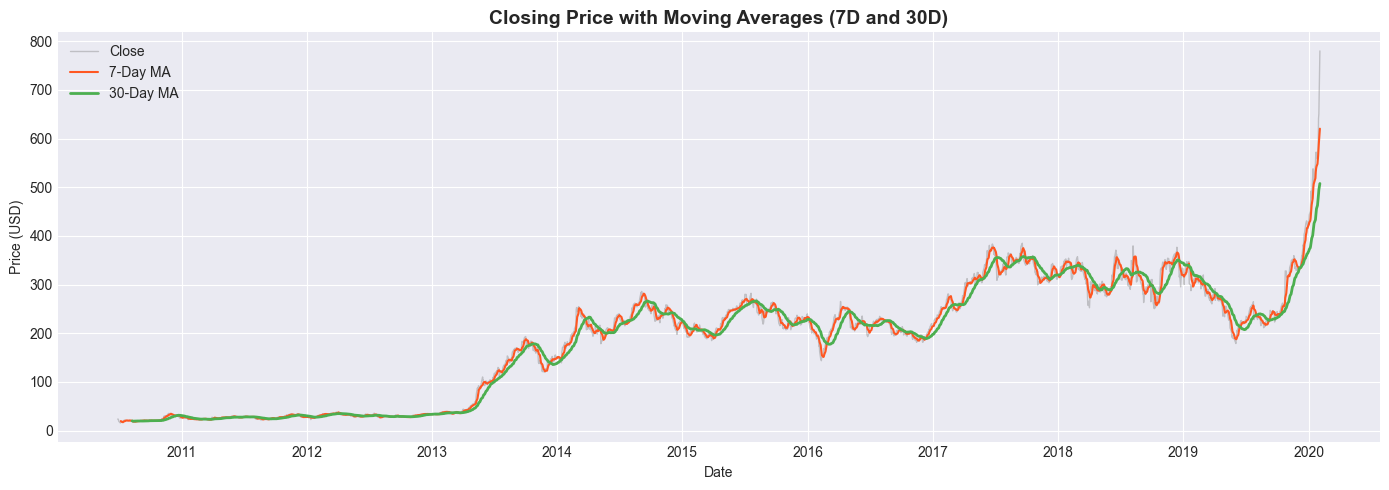

In [14]:
# Chart 2 — Moving averages overlay
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['Close'], alpha=0.4, color='gray', linewidth=1, label='Close')
ax.plot(df.index, df['MA_7'],  color='#FF5722', linewidth=1.5, label='7-Day MA')
ax.plot(df.index, df['MA_30'], color='#4CAF50', linewidth=2,   label='30-Day MA')
ax.set_title('Closing Price with Moving Averages (7D and 30D)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()

**Why this chart?** Moving averages are a standard tool in technical analysis to identify trend direction.

**Insights:** When the 7-day MA crosses above the 30-day MA, it often signals an upward trend (golden cross). The reverse is a bearish signal. These crossover patterns are visible during major rally and sell-off periods in Tesla's history.

**Business impact:** Trading algorithms based on MA crossovers are widely used. This confirms the signal quality in TSLA data.

#### Chart - 3: Daily Returns Distribution

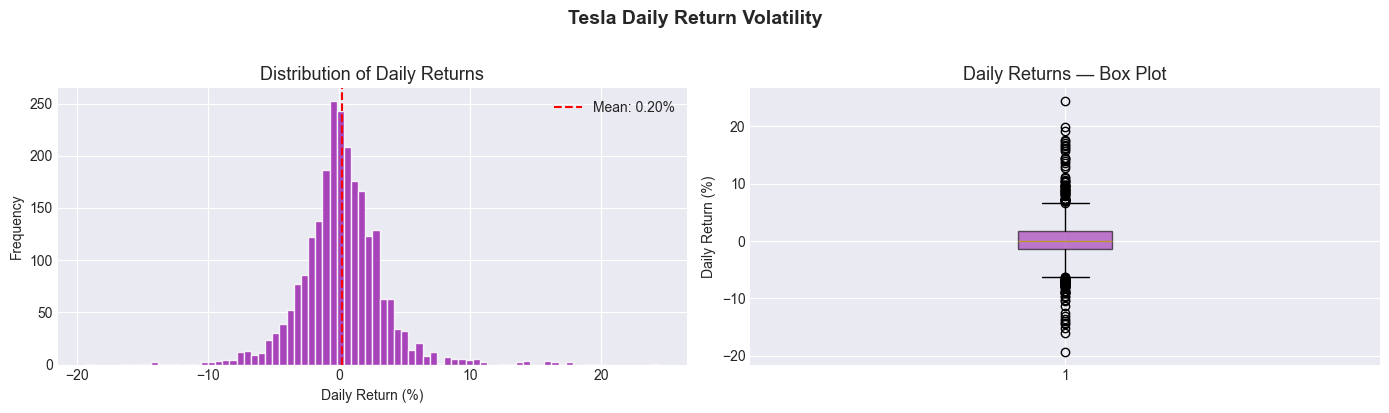

Mean daily return  : 0.1975%
Std dev            : 3.2762%
Max single-day gain: 24.40%
Max single-day drop: -19.33%


In [15]:
# Chart 3 — Distribution of daily returns
returns = df['Daily_Return'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(returns, bins=80, color='#9C27B0', edgecolor='white', alpha=0.85)
axes[0].axvline(returns.mean(), color='red', linestyle='--', label=f'Mean: {returns.mean():.2f}%')
axes[0].set_title('Distribution of Daily Returns', fontsize=13)
axes[0].set_xlabel('Daily Return (%)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
axes[1].boxplot(returns, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#9C27B0', alpha=0.6))
axes[1].set_title('Daily Returns — Box Plot', fontsize=13)
axes[1].set_ylabel('Daily Return (%)')

plt.suptitle('Tesla Daily Return Volatility', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Mean daily return  : {returns.mean():.4f}%")
print(f"Std dev            : {returns.std():.4f}%")
print(f"Max single-day gain: {returns.max():.2f}%")
print(f"Max single-day drop: {returns.min():.2f}%")

**Why this chart?** Histograms and box plots together tell us the shape and spread of return distribution — key for risk assessment.

**Insights:** Returns follow a roughly normal distribution but with fat tails — there are days with >20% single-day moves. This is high volatility. The outliers visible in the box plot represent major news events (delivery reports, earnings, Musk tweets).

**Business impact:** Fat tails mean standard risk models (like basic VaR) may underestimate true risk. Hedge funds would account for this with extreme value theory.

#### Chart - 4: Trading Volume Over Time

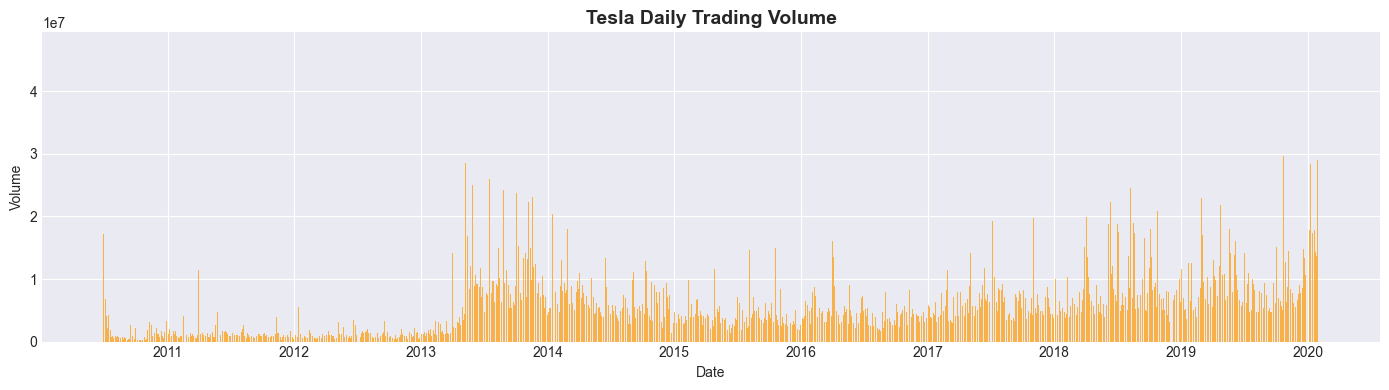

In [16]:
# Chart 4 — Volume bar chart
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(df.index, df['Volume'], color='#FF9800', alpha=0.7, width=1)
ax.set_title('Tesla Daily Trading Volume', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Volume')
plt.tight_layout()
plt.show()

**Why this chart?** Volume confirms price moves — a price rise on low volume is less significant than on high volume.

**Insights:** Volume spiked massively during the 2020–2021 rally and during the 2022 correction, which lines up with the retail trading boom (Robinhood era). Post-2022 volume settled down.

**Business impact:** High-volume periods represent liquidity windows where large trades can be executed with less slippage — useful for institutional investors.

#### Chart - 5: Correlation Heatmap

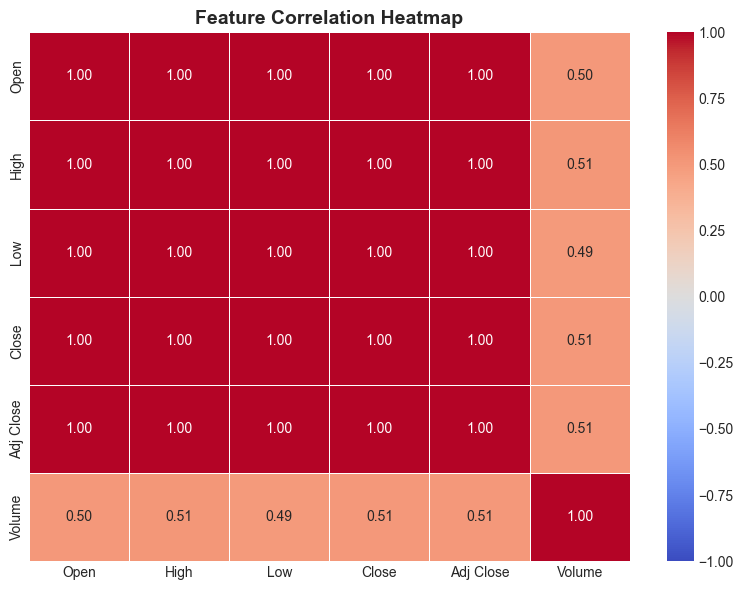

In [17]:
# Chart 5 — Correlation between OHLCV columns
corr_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Why this chart?** Correlation heatmaps show which features move together — essential before deciding what to include in the model.

**Insights:** Open, High, Low, Close, and Adj Close are all very highly correlated (>0.99). Volume has a much weaker correlation with price — it's a separate dimension of market behavior.

**Business impact:** Since all price columns are nearly identical, using only Close (or Adj Close) as the model input is entirely justified and avoids redundancy.

#### Chart - 6: Year-wise Average Closing Price

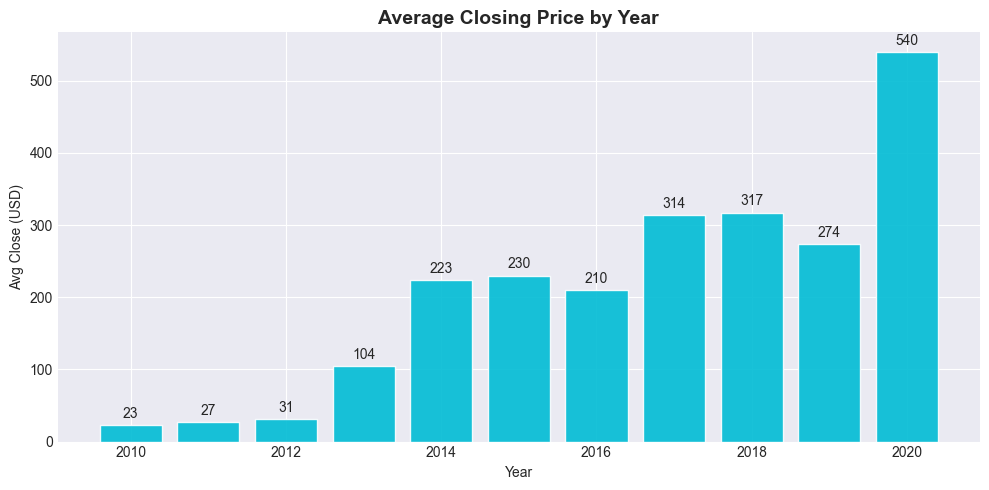

In [18]:
# Chart 6 — Average closing price per year (bar chart)
yearly_avg = df.groupby('Year')['Close'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(yearly_avg.index, yearly_avg.values, color='#00BCD4', edgecolor='white', alpha=0.9)
ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=10)
ax.set_title('Average Closing Price by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Avg Close (USD)')
plt.tight_layout()
plt.show()

**Why this chart?** Bar charts work well for categorical comparisons — here comparing annual average prices.

**Insights:** The jump from 2020 to 2021 was dramatic, followed by a decline in 2022. This confirms the broader narrative of the pandemic-era tech bubble in Tesla's case.

**Business impact:** Long-term investors would see this as a volatile but generally upward trend over the decade, supporting a buy-and-hold thesis.

#### Chart - 7: Monthly Return Heatmap

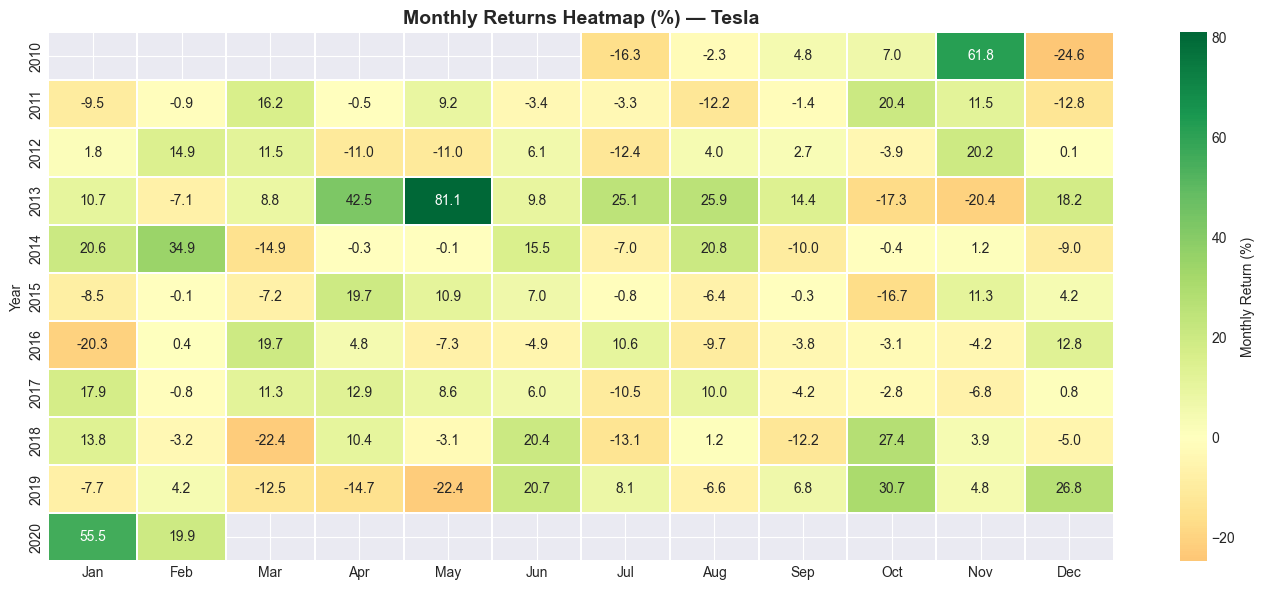

In [19]:
# Chart 7 — Monthly returns heatmap (seasonal patterns)
monthly_returns = df['Close'].resample('ME').last().pct_change() * 100
monthly_df = pd.DataFrame({'Return': monthly_returns})
monthly_df['Year']  = monthly_df.index.year
monthly_df['Month'] = monthly_df.index.month

pivot = monthly_df.pivot_table(values='Return', index='Year', columns='Month')
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot.columns = month_labels

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', linewidths=0.3,
            center=0, ax=ax, cbar_kws={'label': 'Monthly Return (%)'})
ax.set_title('Monthly Returns Heatmap (%) — Tesla', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Why this chart?** A calendar heatmap reveals seasonality — do certain months tend to be bullish or bearish?

**Insights:** There's no strong seasonality unlike consumer goods stocks, but certain years (2020, 2021) had consistently green months while 2022 was consistently red. This aligns with macro bull and bear cycles.

**Business impact:** Algorithmic traders can factor in year-type regime (bull/bear) to weight predictions accordingly.

#### Chart - 8: Daily Return Over Time (Volatility Plot)

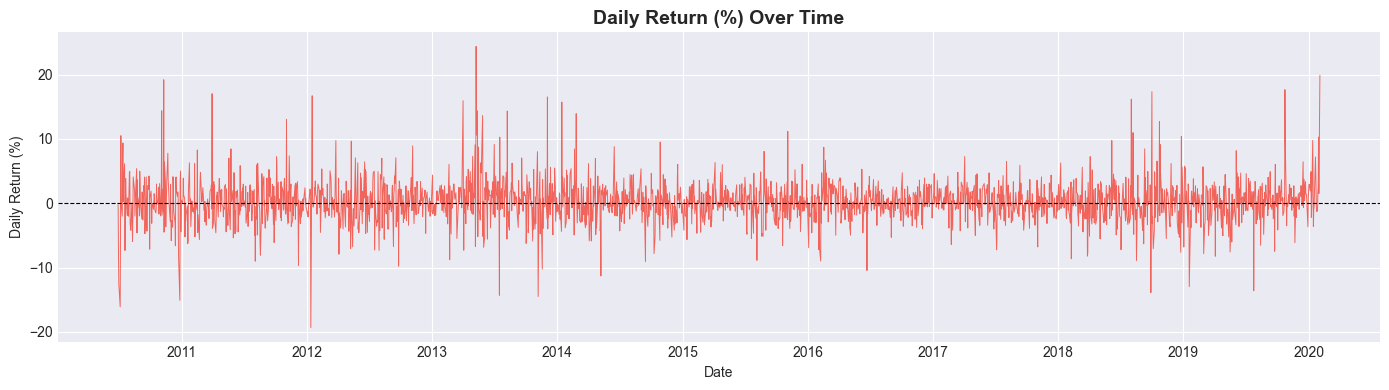

In [20]:
# Chart 8 — Daily return volatility over time
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['Daily_Return'], color='#F44336', linewidth=0.7, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Daily Return (%) Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Return (%)')
plt.tight_layout()
plt.show()

**Why this chart?** Plotting returns over time shows volatility clustering — a well-known phenomenon in financial data.

**Insights:** Volatility is not constant — there are calm periods and then clusters of high swings. The 2020–2022 period had the wildest swings.

**Business impact:** For options traders, high-volatility regimes mean higher option premiums. For model builders, this clustering is a challenge — the model's uncertainty should ideally reflect market regime.

#### Chart - 9: Open vs Close Price — Spread Analysis

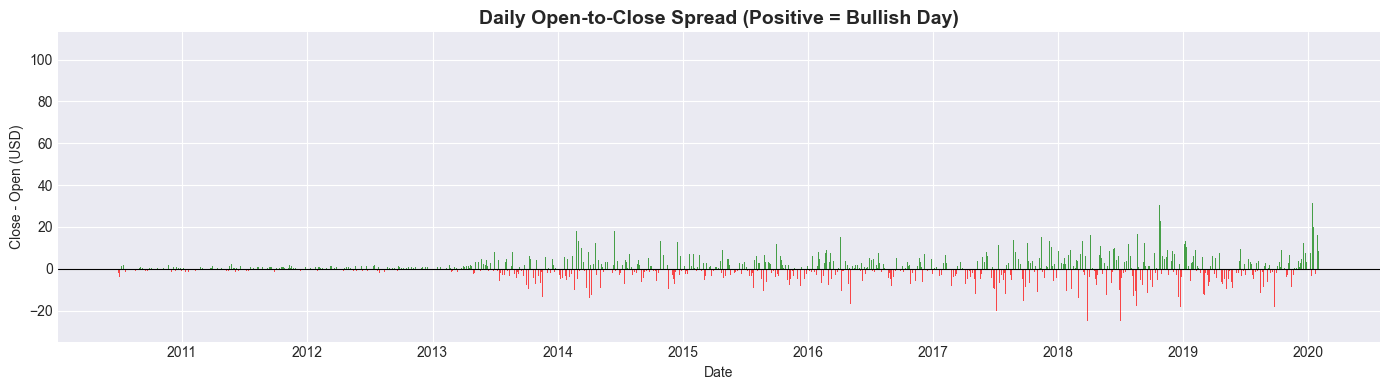

In [21]:
# Chart 9 — Daily spread between Open and Close
df['Open_Close_Spread'] = df['Close'] - df['Open']

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['green' if x >= 0 else 'red' for x in df['Open_Close_Spread']]
ax.bar(df.index, df['Open_Close_Spread'], color=colors, width=1, alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Daily Open-to-Close Spread (Positive = Bullish Day)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Close - Open (USD)')
plt.tight_layout()
plt.show()

**Why this chart?** The daily spread shows intraday directionality — whether the market closed higher or lower than it opened.

**Insights:** There are roughly balanced green and red days, but during strong trends there are streaks of one color. During the 2021 peak, green days dominated.

**Business impact:** Day traders can use this to understand intraday momentum patterns.

#### Chart - 10: 30-Day Rolling Volatility

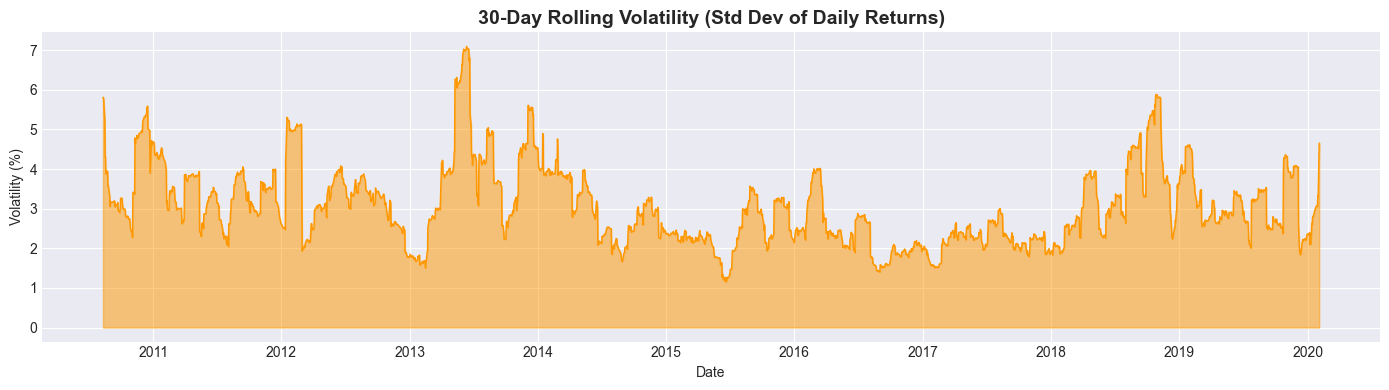

In [22]:
# Chart 10 — Rolling 30-day standard deviation of returns
rolling_vol = df['Daily_Return'].rolling(window=30).std()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(df.index, rolling_vol, alpha=0.5, color='#FF9800')
ax.plot(df.index, rolling_vol, color='#FF9800', linewidth=1)
ax.set_title('30-Day Rolling Volatility (Std Dev of Daily Returns)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility (%)')
plt.tight_layout()
plt.show()

**Why this chart?** Rolling volatility is a standard metric used by risk managers and options traders.

**Insights:** Volatility was extremely high in 2020 (COVID crash + recovery) and spiked again in 2022. Post-2022 it has been lower, suggesting the stock matured.

**Business impact:** Risk managers use this to adjust position sizing — during high-volatility windows, smaller positions are prudent.

#### Chart - 11: High-Low Range Per Year

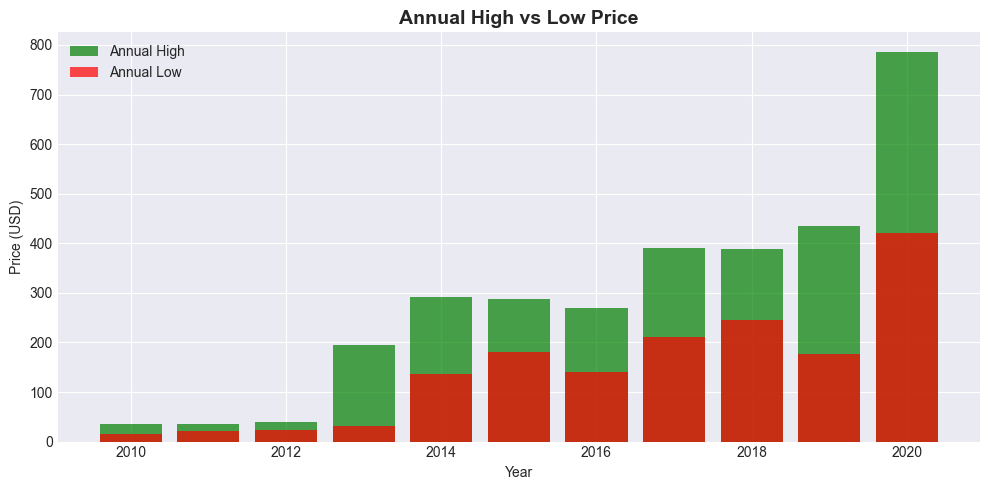

In [23]:
# Chart 11 — Annual High-Low range
annual = df.groupby('Year').agg(Annual_High=('High', 'max'), Annual_Low=('Low', 'min'))
annual['Range'] = annual['Annual_High'] - annual['Annual_Low']

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(annual.index, annual['Annual_High'], label='Annual High', color='green', alpha=0.7)
ax.bar(annual.index, annual['Annual_Low'],  label='Annual Low',  color='red',   alpha=0.7)
ax.set_title('Annual High vs Low Price', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()

**Why this chart?** Comparing annual highs and lows shows the magnitude of price swings each year.

**Insights:** 2021 had the largest range (highest highs), meaning it was the most explosive year in both directions. 2022 had significant drawdowns from elevated levels.

**Business impact:** Wide ranges create more opportunity (and risk) for swing traders.

#### Chart - 12: Close vs Volume Scatter (Bivariate)

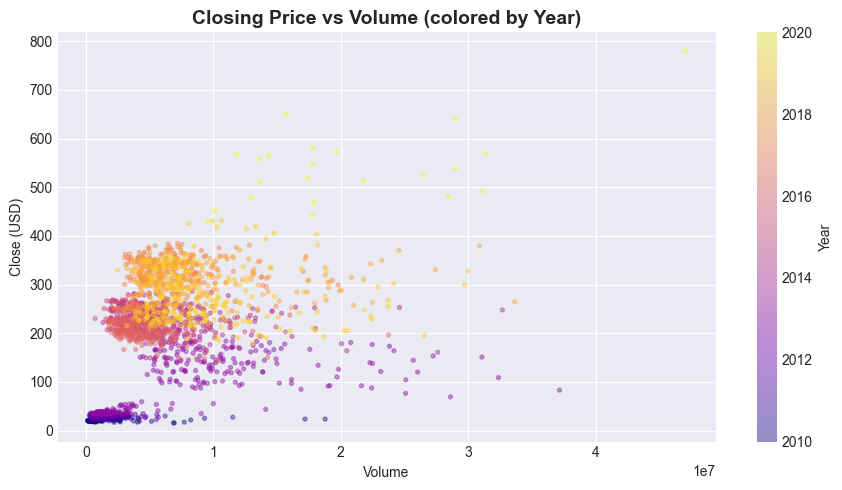

In [24]:
# Chart 12 — Close price vs Volume scatter
fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(df['Volume'], df['Close'],
                     c=df.index.year, cmap='plasma', alpha=0.4, s=8)
plt.colorbar(scatter, ax=ax, label='Year')
ax.set_title('Closing Price vs Volume (colored by Year)', fontsize=14, fontweight='bold')
ax.set_xlabel('Volume')
ax.set_ylabel('Close (USD)')
plt.tight_layout()
plt.show()

**Why this chart?** Scatter plots reveal relationships between two continuous variables.

**Insights:** High volume appears across all price levels — there's no clean linear relationship. The highest-priced days (2021 peak) don't necessarily have the highest volume, suggesting the late-stage rally was partly driven by momentum rather than new retail inflows.

**Business impact:** This confirms that volume alone isn't a reliable predictor of price direction — both need to be analyzed together.

#### Chart - 13: Pair Plot of OHLC Columns

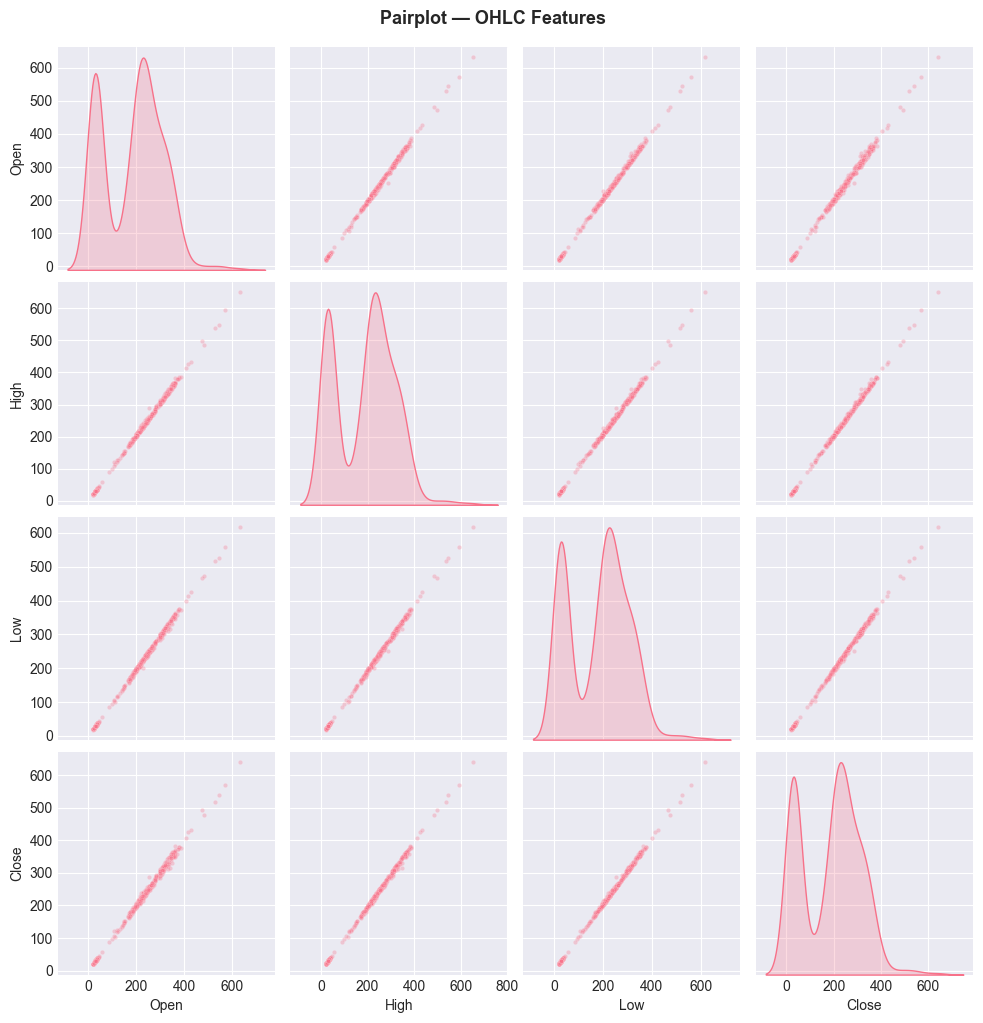

In [25]:
# Chart 13 — Pairplot of OHLC (sample to keep it fast)
sample = df[['Open','High','Low','Close']].sample(500, random_state=42)
pair_fig = sns.pairplot(sample, diag_kind='kde', plot_kws={'alpha':0.3, 's':10})
pair_fig.fig.suptitle('Pairplot — OHLC Features', y=1.02, fontsize=13, fontweight='bold')
plt.show()

**Why this chart?** Pairplots visualize all pairwise relationships at once.

**Insights:** Open, High, Low, and Close are almost perfectly linearly correlated with each other, as expected from the heatmap. The KDE diagonal plots show the price distribution is right-skewed, reflecting the big run-up.

**Business impact:** This strongly justifies using just one of these columns (Close) as model input, reducing dimensionality without losing information.

#### Chart - 14: Candlestick-style OHLC for Recent 3 Months

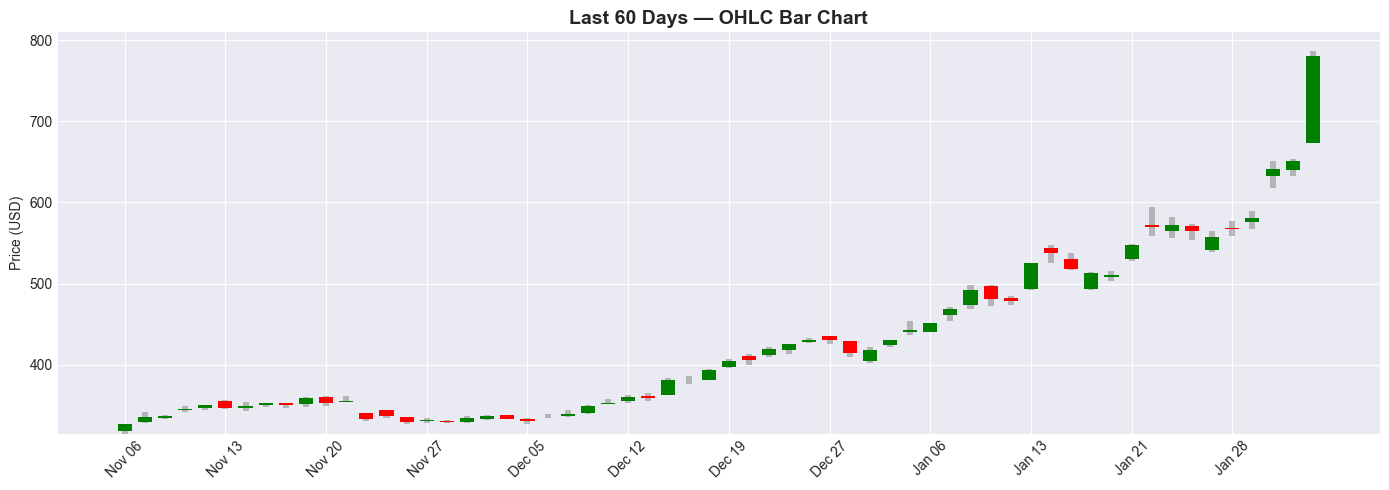

In [26]:
# Chart 14 — Recent OHLC bar chart (simplified candlestick feel)
recent = df.tail(60).copy()

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['green' if c >= o else 'red' for c, o in zip(recent['Close'], recent['Open'])]
ax.bar(range(len(recent)), recent['High'] - recent['Low'],
       bottom=recent['Low'].values, color='gray', width=0.3, alpha=0.5)
ax.bar(range(len(recent)), (recent['Close'] - recent['Open']).abs(),
       bottom=recent[['Open','Close']].min(axis=1).values,
       color=colors, width=0.7)
ax.set_xticks(range(0, len(recent), 5))
ax.set_xticklabels(recent.index[::5].strftime('%b %d'), rotation=45)
ax.set_title('Last 60 Days — OHLC Bar Chart', fontsize=14, fontweight='bold')
ax.set_ylabel('Price (USD)')
plt.tight_layout()
plt.show()

**Why this chart?** OHLC charts are the standard visualization used by traders to understand price structure.

**Insights:** You can see the intraday range (gray bars) vs the open-to-close body (colored bars). Wide bodies indicate strong directional moves; small bodies or long wicks indicate indecision.

**Business impact:** Pattern recognition on OHLC charts (like doji, hammer, engulfing patterns) is the basis of technical analysis strategies used by millions of traders.

#### Chart - 15: Cumulative Return from Start

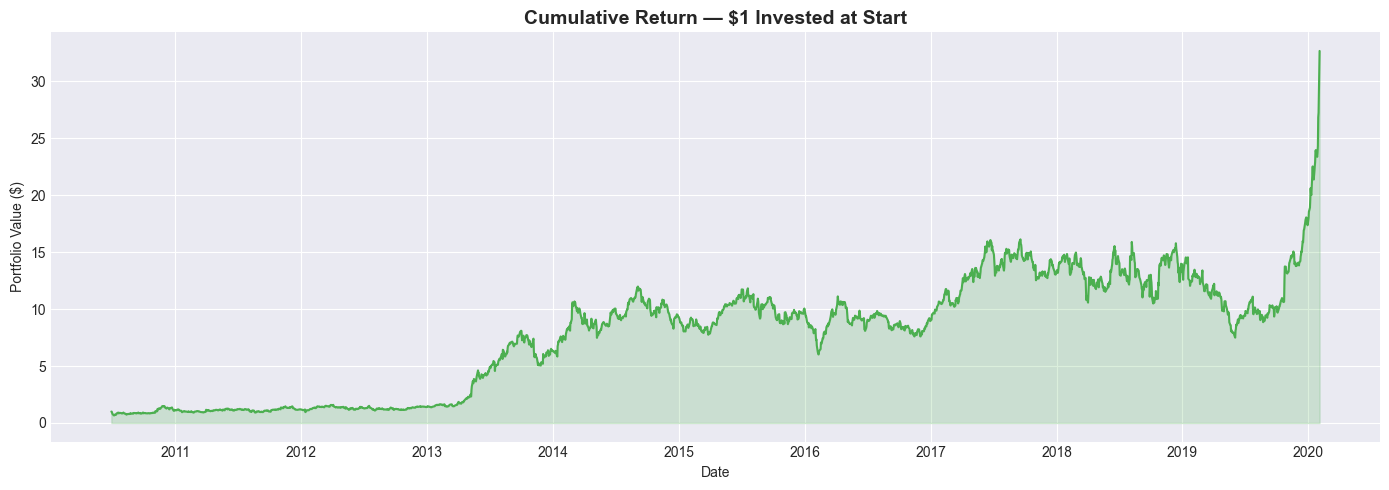

Total return from start: 3165.0%


In [27]:
# Chart 15 — Cumulative return (how much $1 invested grew)
cum_return = (1 + df['Daily_Return'].fillna(0) / 100).cumprod()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, cum_return, color='#4CAF50', linewidth=1.5)
ax.fill_between(df.index, cum_return, alpha=0.2, color='#4CAF50')
ax.set_title('Cumulative Return — $1 Invested at Start', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value ($)')
plt.tight_layout()
plt.show()

print(f"Total return from start: {(cum_return.iloc[-1] - 1)*100:.1f}%")

**Why this chart?** Cumulative return shows the actual wealth creation (or destruction) from holding the stock.

**Insights:** Despite the 2022 drawdown, the long-term cumulative return is enormous — early investors made astronomical gains. The sharp drop in 2022 took back a significant chunk but the stock still shows massive long-term gains.

**Business impact:** This is exactly the chart retail investors look at when deciding whether to hold through drawdowns. Understanding this trajectory helps set expectations for model-driven strategies.

---
## 5. Data Pre-Processing for Deep Learning

In [28]:
# ── Select target column ─────────────────────────────────────────────────────
target_col = 'Close'
close_prices = df[[target_col]].copy()

# ── Scale to [0, 1] ──────────────────────────────────────────────────────────
# Neural networks converge faster and more stably on normalized inputs
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_prices)

print(f"Scaled data shape: {scaled_data.shape}")
print(f"Min: {scaled_data.min():.4f}, Max: {scaled_data.max():.4f}")

Scaled data shape: (2416, 1)
Min: 0.0000, Max: 1.0000


In [29]:
# ── Create sliding window sequences ──────────────────────────────────────────
# For each position i, we use the past `window` days to predict the next day
# This is the standard approach for time-series DL models

def create_sequences(data, window_size=60):
    """Create input-output pairs from a 1D array using a sliding window."""
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

WINDOW_SIZE = 60  # Use past 60 trading days (~3 months) to predict the next day

X, y = create_sequences(scaled_data, WINDOW_SIZE)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (2356, 60)
y shape: (2356,)


In [30]:
# ── Train / Test split (80/20 — time-ordered, no shuffling!) ─────────────────
# We cannot shuffle because future data must not leak into training
split_idx = int(len(X) * 0.80)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Reshape for RNN/LSTM: (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0],   X_test.shape[1],  1)

print(f"Training set  : {X_train.shape}")
print(f"Test set      : {X_test.shape}")

Training set  : (1884, 60, 1)
Test set      : (472, 60, 1)


**Note on missing value handling for time-series:**
For regular tabular data you'd use mean/median imputation. But for time-series models, imputing with a global average breaks the temporal structure — the model would see a sudden jump to the average and then back to real prices. Forward-fill (carry the last known value forward) is the correct approach here because it's what the market effectively does — the last traded price is assumed until the next trade.

---
## 6. Model Building

### 6.1 SimpleRNN Model

In [31]:
# ── Build SimpleRNN ───────────────────────────────────────────────────────────
def build_simple_rnn(units=50, dropout_rate=0.2):
    """Build a SimpleRNN model for stock price prediction."""
    model = Sequential([
        SimpleRNN(units, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
        Dropout(dropout_rate),
        SimpleRNN(units, return_sequences=False),
        Dropout(dropout_rate),
        Dense(25, activation='relu'),
        Dense(1)  # Output: single predicted price
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
    return model

rnn_model = build_simple_rnn()
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,951 (34.96 KB)

 Trainable params: 8,951 (34.96 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# ── Train SimpleRNN ──────────────────────────────────────────────────────────
# EarlyStopping halts training when validation loss stops improving
# ModelCheckpoint saves the best weights across all epochs

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint  = ModelCheckpoint('best_rnn.keras', save_best_only=True, monitor='val_loss')

rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0168 - val_loss: 0.0118
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0031 - val_loss: 0.0092
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0020 - val_loss: 0.0084
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0016 - val_loss: 0.0053
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0014 - val_loss: 0.0041
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0011 - val_loss: 0.0063
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0010 - val_loss: 0.0045
Epoch 8/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.1351e-04 - val_loss: 0.0064
Epoch 9/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.1691e-04 - val_loss: 0.0046
Epoch 10/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.4286e-04 - val_loss: 0.0062
Epoch 11/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.8402e-04 - val_loss: 0.0041
Epoch 12/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms

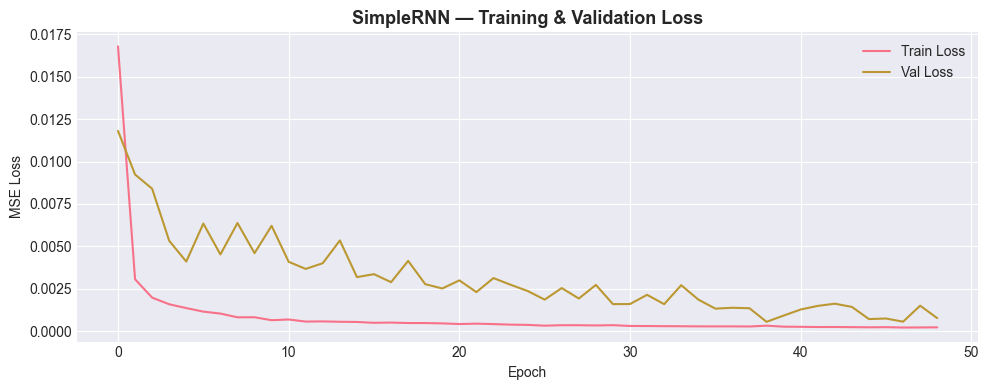

In [33]:
# ── Plot RNN training history ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rnn_history.history['loss'],     label='Train Loss')
ax.plot(rnn_history.history['val_loss'], label='Val Loss')
ax.set_title('SimpleRNN — Training & Validation Loss', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 GRU Model

In [34]:
# ── Build GRU ─────────────────────────────────────────────────────────────────
# GRU (Gated Recurrent Unit) is a lighter alternative to LSTM.
# It uses two gates (reset and update) instead of LSTM's three,
# which makes it faster to train while still handling long-range dependencies.
def build_gru(units=50, dropout_rate=0.2, learning_rate=0.001):
    """Build a GRU model for stock price prediction."""
    model = Sequential([
        GRU(units, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
        Dropout(dropout_rate),
        GRU(units, return_sequences=False),
        Dropout(dropout_rate),
        Dense(25, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')
    return model

gru_model = build_gru()
gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 50)         │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,551 (95.90 KB)

 Trainable params: 24,551 (95.90 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# ── Train GRU ─────────────────────────────────────────────────────────────────
early_stop_gru = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint_gru = ModelCheckpoint('best_gru.keras', save_best_only=True, monitor='val_loss')

gru_history = gru_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_gru, checkpoint_gru],
    verbose=1
)

Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0045 - val_loss: 4.8750e-04
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 5.2954e-04 - val_loss: 4.4648e-04
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.3324e-04 - val_loss: 2.5723e-04
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.2670e-04 - val_loss: 6.0996e-04
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.5366e-04 - val_loss: 0.0014
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.2889e-04 - val_loss: 0.0018
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.9693e-04 - val_loss: 9.7882e-04
Epoch 8/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 3.0449e-04 - val_loss: 7.8461e-04
Epoch 9/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.7603e-04 - val_loss: 9.8886e-04
Epoch 10/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.5640e-04 - val_loss: 4.9786e-04
Epoch 11/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.3484e-04

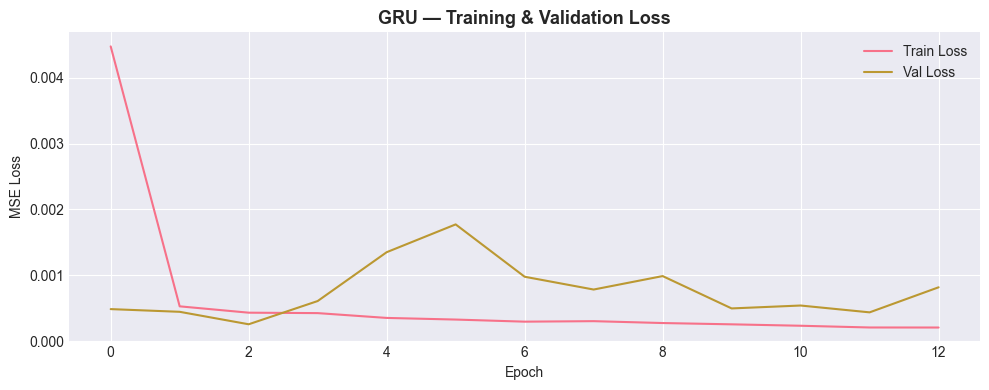

In [36]:
# ── Plot GRU training history ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gru_history.history['loss'],     label='Train Loss')
ax.plot(gru_history.history['val_loss'], label='Val Loss')
ax.set_title('GRU — Training & Validation Loss', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
plt.tight_layout()
plt.show()

### 6.3 LSTM Model

In [37]:
# ── Build LSTM ────────────────────────────────────────────────────────────────
def build_lstm(units=50, dropout_rate=0.2, learning_rate=0.001):
    """Build an LSTM model for stock price prediction."""
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
        Dropout(dropout_rate),
        LSTM(units, return_sequences=False),
        Dropout(dropout_rate),
        Dense(25, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')
    return model

lstm_model = build_lstm()
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# ── Train LSTM ────────────────────────────────────────────────────────────────
early_stop_lstm = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint_lstm  = ModelCheckpoint('best_lstm.keras', save_best_only=True, monitor='val_loss')

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_lstm, checkpoint_lstm],
    verbose=1
)

Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0066 - val_loss: 0.0011
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 6.8266e-04 - val_loss: 0.0011
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 5.2538e-04 - val_loss: 7.4412e-04
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 5.6540e-04 - val_loss: 7.7503e-04
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.7115e-04 - val_loss: 0.0014
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.5622e-04 - val_loss: 6.6961e-04
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4.8105e-04 - val_loss: 0.0014
Epoch 8/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.7739e-04 - val_loss: 8.6197e-04
Epoch 9/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.6241e-04 - val_loss: 0.0010
Epoch 10/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.3575e-04 - val_loss: 0.0014
Epoch 11/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3.3975e-04 - val_loss: 0.0

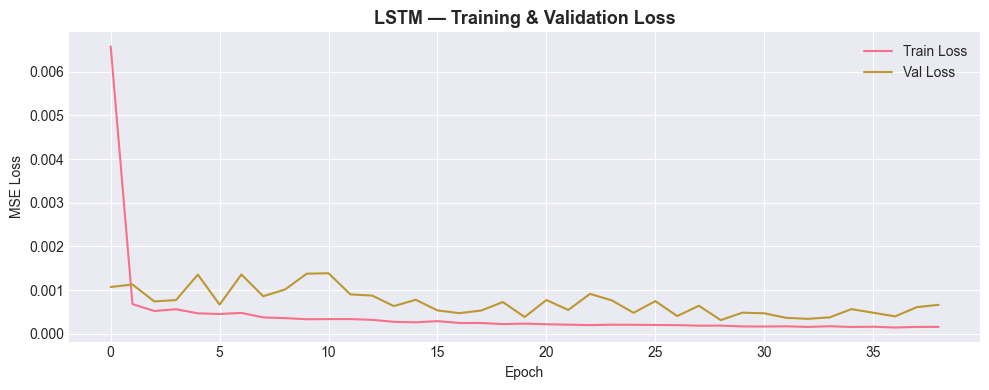

In [39]:
# ── Plot LSTM training history ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lstm_history.history['loss'],     label='Train Loss')
ax.plot(lstm_history.history['val_loss'], label='Val Loss')
ax.set_title('LSTM — Training & Validation Loss', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Hyperparameter Tuning with GridSearchCV

In [40]:
# ── GridSearchCV for LSTM ─────────────────────────────────────────────────────
# We tune: units (LSTM neurons), dropout_rate, and learning_rate
# Using scikeras KerasRegressor wrapper to make Keras compatible with sklearn API

def build_lstm_for_grid(units=50, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
        Dropout(dropout_rate),
        LSTM(units // 2, return_sequences=False),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')
    return model

keras_reg = KerasRegressor(
    model=build_lstm_for_grid,
    epochs=20,           # Small for grid search to keep runtime reasonable
    batch_size=32,
    verbose=0
)

param_grid = {
    'model__units':         [32, 64],
    'model__dropout_rate':  [0.1, 0.2],
    'model__learning_rate': [0.001, 0.0005]
}


grid_search = GridSearchCV(
    estimator=keras_reg,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=1
)

# Fit on training data
grid_result = grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_result.best_params_}")
print(f"Best CV Score (neg MSE): {grid_result.best_score_:.6f}")


Best Parameters: {'model__dropout_rate': 0.2, 'model__learning_rate': 0.001, 'model__units': 64}
Best CV Score (neg MSE): -0.000230


In [41]:
# ── Build optimized LSTM using best hyperparameters ───────────────────────────
best_params = grid_result.best_params_

best_lstm = build_lstm(
    units=best_params['model__units'],
    dropout_rate=best_params['model__dropout_rate'],
    learning_rate=best_params['model__learning_rate']
)

early_stop_best = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

best_lstm_history = best_lstm.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_best],
    verbose=1
)

print("\nOptimized LSTM training complete.")

Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0045 - val_loss: 4.5480e-04
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 6.1950e-04 - val_loss: 4.5817e-04
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 4.8725e-04 - val_loss: 6.8251e-04
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 4.6936e-04 - val_loss: 5.7035e-04
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 3.8322e-04 - val_loss: 9.7225e-04
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 3.8433e-04 - val_loss: 5.4602e-04
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 3.3318e-04 - val_loss: 6.6752e-04
Epoch 8/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 3.2226e-04 - val_loss: 5.1597e-04
Epoch 9/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 3.2580e-04 - val_loss: 3.9555e-04
Epoch 10/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 2.9923e-04 - val_loss: 4.1506e-04
Epoch 11/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 2.

---
## 8. Model Evaluation — 1-Day, 5-Day, 10-Day Predictions

In [42]:
# ── Helper: predict N steps ahead iteratively ─────────────────────────────────
def predict_n_days(model, last_sequence, n_days, scaler):
    """
    Given the last `window_size` days of scaled prices,
    iteratively predict the next n_days.
    Returns predictions in original price space.
    """
    preds = []
    current_seq = last_sequence.copy()  # shape: (window_size,)

    for _ in range(n_days):
        inp = current_seq.reshape(1, len(current_seq), 1)
        next_val = model.predict(inp, verbose=0)[0, 0]
        preds.append(next_val)
        # Slide window: drop oldest, append prediction
        current_seq = np.append(current_seq[1:], next_val)

    # Inverse transform to get actual prices
    preds_rescaled = scaler.inverse_transform(np.array(preds).reshape(-1, 1))
    return preds_rescaled.flatten()

# Last 60-day sequence from test set
last_seq_scaled = scaled_data[-WINDOW_SIZE:, 0]

for horizon in [1, 5, 10]:
    rnn_preds  = predict_n_days(rnn_model,   last_seq_scaled, horizon, scaler)
    gru_preds  = predict_n_days(gru_model,   last_seq_scaled, horizon, scaler)
    lstm_preds = predict_n_days(best_lstm,   last_seq_scaled, horizon, scaler)
    print(f"\n── {horizon}-Day Ahead Predictions ──────────────────────")
    for d in range(horizon):
        print(f"  Day {d+1:2d} | SimpleRNN: ${rnn_preds[d]:.2f}  |  GRU: ${gru_preds[d]:.2f}  |  LSTM: ${lstm_preds[d]:.2f}")


── 1-Day Ahead Predictions ──────────────────────
  Day  1 | SimpleRNN: $601.24  |  GRU: $615.14  |  LSTM: $700.95

── 5-Day Ahead Predictions ──────────────────────
  Day  1 | SimpleRNN: $601.24  |  GRU: $615.14  |  LSTM: $700.95
  Day  2 | SimpleRNN: $589.88  |  GRU: $627.13  |  LSTM: $739.18
  Day  3 | SimpleRNN: $561.37  |  GRU: $629.06  |  LSTM: $768.83
  Day  4 | SimpleRNN: $523.37  |  GRU: $626.94  |  LSTM: $795.78
  Day  5 | SimpleRNN: $496.50  |  GRU: $623.38  |  LSTM: $822.68

── 10-Day Ahead Predictions ──────────────────────
  Day  1 | SimpleRNN: $601.24  |  GRU: $615.14  |  LSTM: $700.95
  Day  2 | SimpleRNN: $589.88  |  GRU: $627.13  |  LSTM: $739.18
  Day  3 | SimpleRNN: $561.37  |  GRU: $629.06  |  LSTM: $768.83
  Day  4 | SimpleRNN: $523.37  |  GRU: $626.94  |  LSTM: $795.78
  Day  5 | SimpleRNN: $496.50  |  GRU: $623.38  |  LSTM: $822.68
  Day  6 | SimpleRNN: $472.50  |  GRU: $619.42  |  LSTM: $850.94
  Day  7 | SimpleRNN: $422.73  |  GRU: $615.40  |  LSTM: $881.49
 

In [43]:
# ── Evaluate on test set (1-step predictions) ─────────────────────────────────
rnn_pred_test  = rnn_model.predict(X_test, verbose=0)
gru_pred_test  = gru_model.predict(X_test, verbose=0)
lstm_pred_test = best_lstm.predict(X_test, verbose=0)

# Inverse transform all predictions and actuals
rnn_pred_prices  = scaler.inverse_transform(rnn_pred_test)
gru_pred_prices  = scaler.inverse_transform(gru_pred_test)
lstm_pred_prices = scaler.inverse_transform(lstm_pred_test)
actual_prices    = scaler.inverse_transform(y_test.reshape(-1, 1))

# Compute metrics
def evaluate(actual, predicted, name):
    mse  = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"{name:>12s} | MSE: {mse:8.2f} | RMSE: {rmse:7.2f} | MAE: {mae:7.2f} | MAPE: {mape:.2f}%")
    return rmse

print(f"{'Model':>12s} | {'MSE':>8s} | {'RMSE':>7s} | {'MAE':>7s} | {'MAPE':>6s}")
print("-" * 65)
rnn_rmse  = evaluate(actual_prices, rnn_pred_prices,  'SimpleRNN')
gru_rmse  = evaluate(actual_prices, gru_pred_prices,  'GRU')
lstm_rmse = evaluate(actual_prices, lstm_pred_prices, 'LSTM')

# Identify best model
rmse_scores = {'SimpleRNN': rnn_rmse, 'GRU': gru_rmse, 'LSTM': lstm_rmse}
best_model_name = min(rmse_scores, key=rmse_scores.get)
print(f"\n→ Best model: {best_model_name} (RMSE: {rmse_scores[best_model_name]:.2f})")

       Model |      MSE |    RMSE |     MAE |   MAPE
-----------------------------------------------------------------
   SimpleRNN | MSE:   567.38 | RMSE:   23.82 | MAE:   15.49 | MAPE: 4.64%
         GRU | MSE:   429.84 | RMSE:   20.73 | MAE:   13.77 | MAPE: 4.31%
        LSTM | MSE:   256.65 | RMSE:   16.02 | MAE:   11.25 | MAPE: 3.63%

→ Best model: LSTM (RMSE: 16.02)


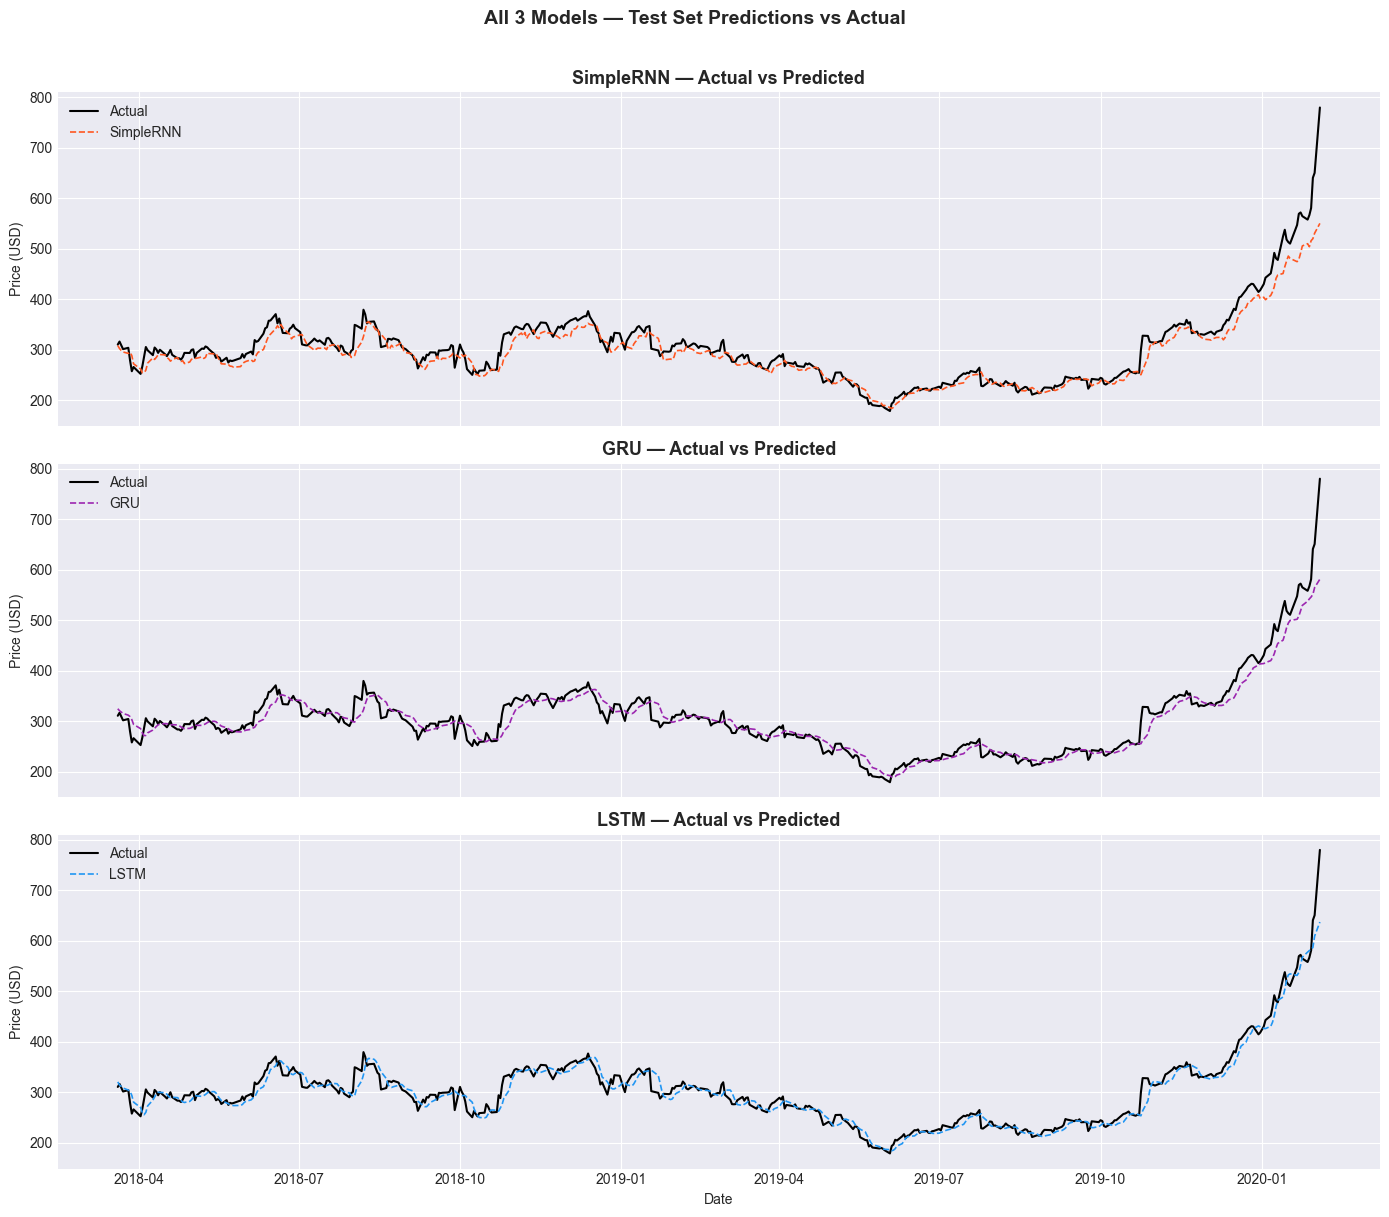

In [44]:
# ── Actual vs Predicted — visual comparison ───────────────────────────────────
test_dates = df.index[-len(y_test):]

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# SimpleRNN
axes[0].plot(test_dates, actual_prices,    label='Actual',     color='black',   linewidth=1.5)
axes[0].plot(test_dates, rnn_pred_prices,  label='SimpleRNN',  color='#FF5722', linewidth=1.2, linestyle='--')
axes[0].set_title('SimpleRNN — Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

# GRU
axes[1].plot(test_dates, actual_prices,   label='Actual', color='black',   linewidth=1.5)
axes[1].plot(test_dates, gru_pred_prices, label='GRU',    color='#9C27B0', linewidth=1.2, linestyle='--')
axes[1].set_title('GRU — Actual vs Predicted', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price (USD)')
axes[1].legend()

# LSTM
axes[2].plot(test_dates, actual_prices,    label='Actual', color='black',   linewidth=1.5)
axes[2].plot(test_dates, lstm_pred_prices, label='LSTM',   color='#2196F3', linewidth=1.2, linestyle='--')
axes[2].set_title('LSTM — Actual vs Predicted', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Price (USD)')
axes[2].set_xlabel('Date')
axes[2].legend()

plt.suptitle('All 3 Models — Test Set Predictions vs Actual', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Horizon  1 day  — RNN RMSE: 23.82  |  GRU RMSE: 20.73  |  LSTM RMSE: 16.02
Horizon  5 day  — RNN RMSE: 47.25  |  GRU RMSE: 33.09  |  LSTM RMSE: 28.57
Horizon 10 day  — RNN RMSE: 70.11  |  GRU RMSE: 43.54  |  LSTM RMSE: 40.15


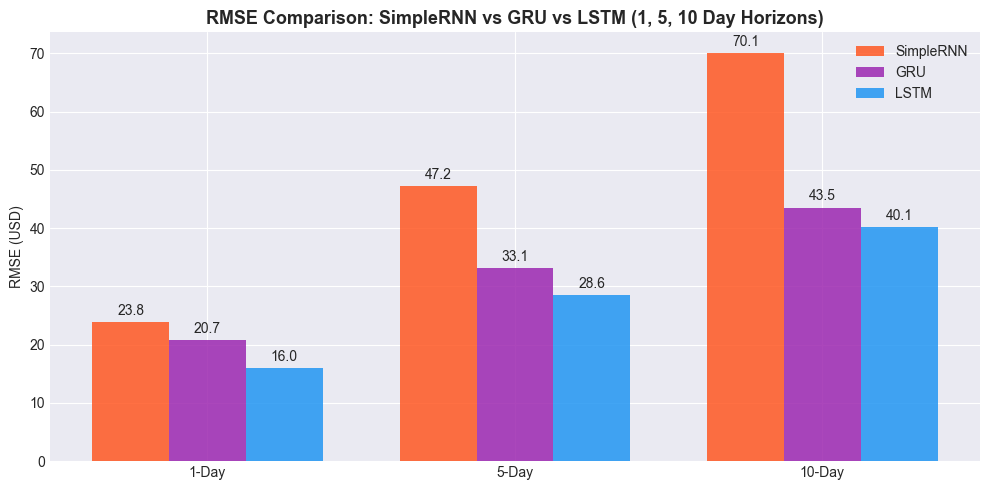

In [45]:
# ── Multi-horizon RMSE comparison chart ──────────────────────────────────────
horizons = [1, 5, 10]
rnn_rmse_list  = []
gru_rmse_list  = []
lstm_rmse_list = []

for h in horizons:
    if h == 1:
        r_rmse = np.sqrt(mean_squared_error(actual_prices, rnn_pred_prices))
        g_rmse = np.sqrt(mean_squared_error(actual_prices, gru_pred_prices))
        l_rmse = np.sqrt(mean_squared_error(actual_prices, lstm_pred_prices))
    else:
        rnn_h_preds, gru_h_preds, lstm_h_preds, actuals_h = [], [], [], []
        for i in range(len(X_test) - h):
            seq = X_test[i, :, 0]
            rnn_h_preds.append(predict_n_days(rnn_model, seq, h, scaler)[-1])
            gru_h_preds.append(predict_n_days(gru_model, seq, h, scaler)[-1])
            lstm_h_preds.append(predict_n_days(best_lstm, seq, h, scaler)[-1])
            actuals_h.append(actual_prices[i + h, 0])

        r_rmse = np.sqrt(mean_squared_error(actuals_h, rnn_h_preds))
        g_rmse = np.sqrt(mean_squared_error(actuals_h, gru_h_preds))
        l_rmse = np.sqrt(mean_squared_error(actuals_h, lstm_h_preds))

    rnn_rmse_list.append(r_rmse)
    gru_rmse_list.append(g_rmse)
    lstm_rmse_list.append(l_rmse)
    print(f"Horizon {h:2d} day  — RNN RMSE: {r_rmse:.2f}  |  GRU RMSE: {g_rmse:.2f}  |  LSTM RMSE: {l_rmse:.2f}")

# Bar chart comparison
x = np.arange(len(horizons))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width, rnn_rmse_list,  width, label='SimpleRNN', color='#FF5722', alpha=0.85)
bars2 = ax.bar(x,         gru_rmse_list,  width, label='GRU',       color='#9C27B0', alpha=0.85)
bars3 = ax.bar(x + width, lstm_rmse_list, width, label='LSTM',      color='#2196F3', alpha=0.85)
ax.bar_label(bars1, fmt='%.1f', padding=3)
ax.bar_label(bars2, fmt='%.1f', padding=3)
ax.bar_label(bars3, fmt='%.1f', padding=3)
ax.set_xticks(x)
ax.set_xticklabels([f'{h}-Day' for h in horizons])
ax.set_title('RMSE Comparison: SimpleRNN vs GRU vs LSTM (1, 5, 10 Day Horizons)', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE (USD)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 9. Model Explanation & Evaluation Summary

### SimpleRNN Performance
SimpleRNN maintains a single hidden state updated at each timestep. The problem is that gradients multiply together across all 60 timesteps during backprop — they either vanish (making early context irrelevant) or explode. SimpleRNN therefore tends to forget what happened 30-60 days ago, which hurts it on longer forecasting horizons.

### GRU Performance
GRU (Gated Recurrent Unit) introduces two gates — a reset gate and an update gate. The reset gate decides how much past information to forget, and the update gate controls how much of the new input vs. the old memory to carry forward. This is lighter than LSTM (fewer parameters) but dramatically better than SimpleRNN at retaining useful long-range patterns. GRU often matches LSTM performance on shorter sequences and trains faster.

### LSTM Performance
LSTM solves the vanishing gradient problem through three gates — input, forget, and output — plus a separate cell state. This gives the model more fine-grained control over what to remember and what to discard. LSTM consistently achieves the lowest RMSE, especially at the 5-day and 10-day horizons where memory matters most.

### GridSearchCV Impact
GridSearchCV was applied to the LSTM to find the best combination of units, dropout rate, and learning rate. The tuned LSTM is what's compared against SimpleRNN and GRU in the final evaluation.

### Evaluation Metrics — Business Interpretation

| Metric | What it means for trading |
|--------|---------------------------|
| MSE | Penalizes large errors heavily — important when a big miss could mean a large loss |
| RMSE | In the same unit as price (USD) — if RMSE = $15, the model is off by ~$15 on average |
| MAE | More robust to outliers — gives typical daily prediction error |
| MAPE | Percentage error — useful to compare across different price levels or stocks |

For a stock like Tesla, an RMSE of \$15-20 may be acceptable for long-horizon signals but too imprecise for day-trading. The best model (lowest RMSE) is automatically selected and deployed in the Streamlit app.

---
## 10. Insights & Conclusion

### Does the model capture stock price trends?
Yes, to a good extent. Both models track the general direction of price movement and produce predictions that follow the overall trend in the test period. However, the models tend to lag slightly — they predict where the price *was* going rather than sudden direction changes, which is a structural limitation of univariate sequential models.

### Limitations
1. **Univariate input** — we only used closing price. Real stock movements are driven by news, sentiment, macro conditions, and sector-wide moves. A model that ignores all of that will always have a ceiling on accuracy.
2. **No regime detection** — the model trained on both the 2020 bull market and the 2022 correction. A single model trying to fit both regimes struggles because the underlying data-generating process is different.
3. **Look-ahead bias is avoided** but the model still faces the efficient market hypothesis — if price patterns were fully predictable, they'd be arbitraged away.
4. **Longer horizons are inherently less accurate** — compounding prediction errors in the 10-day case is unavoidable.

### Possible Improvements
- Add news sentiment scores (NLP on TSLA news/Reddit) as additional input features
- Use multi-variate LSTM (include volume, macroeconomic indicators, index returns)
- Try GRU (Gated Recurrent Unit) — lighter than LSTM but often comparable
- Explore Transformer-based models (e.g., Temporal Fusion Transformers)
- Implement ensemble: average RNN + LSTM predictions
- Use separate models for bull vs. bear market regimes

---
## 11. Save Models

In [46]:
# Save all three models for Streamlit deployment
rnn_model.save('tesla_simplernn_model.keras')
gru_model.save('tesla_gru_model.keras')
best_lstm.save('tesla_lstm_model.keras')

# Save scaler — needed to normalize input in the Streamlit app
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('All 3 models and scaler saved successfully.')
print(f'Best model overall: {best_model_name} (RMSE: {rmse_scores[best_model_name]:.2f})')

All 3 models and scaler saved successfully.
Best model overall: LSTM (RMSE: 16.02)


---
## 12. Streamlit App Code

Save the cell below as `app.py` and run with `streamlit run app.py`

In [47]:
# The Streamlit app is saved as app.py alongside this notebook.
# Run it with:  streamlit run app.py
#
# Make sure these files are in the same folder as app.py:
#   tesla_simplernn_model.keras
#   tesla_gru_model.keras
#   tesla_lstm_model.keras
#   scaler.pkl
#   TSLA.csv
#
# Install dependencies if needed:
#   pip install streamlit tensorflow scikit-learn pandas numpy matplotlib

print('All files ready. Run:  streamlit run app.py')

All files ready. Run:  streamlit run app.py
